In [1]:
import networkExpansionPy.folds as nf
import pandas as pd
import pickle
from collections import Counter
from pathlib import PurePath, Path

# seed = sys.argv[1]
# random.seed(seed)
asset_path = nf.asset_path

# for vanilla
METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

# for FOLD-GATED
ALGORITHM = "no_look_ahead_rules"
WRITE = True # write result to disk
WRITE_TMP = False # write after each iteration
CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
STR_TO_APPEND_TO_FNAME = None # if writing result, str to append to filename
ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

## Metabolism
metabolism = pd.read_pickle(METABOLISM_PATH)
# remove reactions that produce H2O2 before O2
H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
metabolism.network = metabolism.network[~condition]
assert 'R00017_v1' not in list(metabolism.network['rn'])

## Ablation
# metabolism.pruneReactionsFromMetabolite(['C00007'])
# metabolism.pruneReactionsFromMetabolite(['Z00032'])
# metabolism.pruneReactionsFromMetabolite(['C00006'])

## FoldRules
rn2rules = pd.read_pickle(RN2RULES_PATH)
foldrules = nf.FoldRules.from_rn2rules(rn2rules)

## Modify seeds with AA and GATP_rns
aa_cids = set(["C00037",
    "C00041",
    "C00065",
    "C00188",
    "C00183",
    "C00407",
    "C00123",
    "C00148",
    "C00049",
    "C00025"])

# 70 seed cpds
# aa_cids = set([])

GATP_rns = {'R00200_gATP_v1',
    'R00200_gATP_v2',
    'R00430_gGTP_v1',
    'R00430_gGTP_v2',
    'R01523_gATP_v1',
    'R04144_gATP_v1',
    'R04208_gATP',
    'R04463_gATP',
    'R04591_gATP_v1',
    'R06836_gATP',
    'R06974_gATP',
    'R06975_gATP_v1'}


## Seed
seed = nf.Params(
    rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
    cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
    folds = set(['spontaneous'])
)

## Seed with pre-expansion
# preALL = pd.read_pickle('../data/pre-expansion_seed_cpds/pre-expansion_seed_cpds_ALL.pkl')
# seed = nf.Params(
#     rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#     cpds = set(preALL) | aa_cids,
#     folds = set(['spontaneous'])
# )

# ## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)

# ## run FOLD-GATED expansion
# result = fm.rule_order(algorithm=ALGORITHM, write=WRITE, write_tmp=WRITE_TMP, path=CUSTOM_WRITE_PATH, str_to_append_to_fname=STR_TO_APPEND_TO_FNAME, ordered_outcome=ORDERED_OUTCOME, ignore_reaction_versions=IGNORE_REACTION_VERSIONS)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:535: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.


# save result object

In [1]:
# with open('../data/assets/vanilla_result_object.pkl', 'wb') as file:
#     pickle.dump(fm, file)

# len(fm.seed.cpds)

# making 'rns_unreached_wo_cofactor' pkl files

In [20]:
full_fm = fm

In [22]:
len(full_fm.scope.rns)

7678

In [17]:
len(fm.scope.cpds), len(fm.scope.rns)

(3332, 6005)

In [23]:
len(full_fm.scope.rns - fm.scope.rns)

1673

In [25]:
full_rns_scope = full_fm.scope.rns

In [26]:
print(len(full_rns_scope), len(fm.scope.rns))

my_set = full_rns_scope - fm.scope.rns
print(len(my_set))

7678 6005
1673


In [27]:
with open('../data/rns_unreached_wo/rns_unreached_wo_O2.pkl', 'wb') as file:
    pickle.dump(my_set, file)

# AA order

In [4]:
# import pandas as pd
# from scipy.stats import spearmanr

# # Data extracted from the image
# data = {
#     "amino acid": ["V", "G", "I", "M", "A", "T", "H", "E", "C", "P", "K", "S", "D", "L", "N", "R", "F", "Y", "Q", "W"],
#     "Amio Acid Order (Wehbi)": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
#     "Amino Acid Order (Trifinov)": [4, 2, 14, 18, 2, 9, 16, 8, 15, 5, 12, 6, 4, 8, 11, 10, 17, 19, 13, 20],
#     "Amino Acid Order (Goldford)": [18, 4, 19, 13, 9, 9, 14, 1, 9, 10, 11, 9, 2, 20, 4, 12, 16, 16, 5, 18],
#     "Split form Ancestor (IQ-TREE)": [7, None, 8, 5, None, None, None, 3, 3, None, 3, None, None, 5, None, 2, None, 2, 2, 2]
# }

# # Create a DataFrame
# df = pd.DataFrame(data)

# # Drop rows where "Split form Ancestor (IQ-TREE)" is None
# df_clean = df.dropna(subset=["Split form Ancestor (IQ-TREE)"])

# # Calculate Spearman correlation for each amino acid order
# results = {}
# for column in ["Amio Acid Order (Wehbi)", "Amino Acid Order (Trifinov)", "Amino Acid Order (Goldford)"]:
#     corr, _ = spearmanr(df_clean[column], df_clean["Split form Ancestor (IQ-TREE)"])
#     results[column] = corr

# results

# checking 'version # change' behavior

In [4]:
asset_path = nf.asset_path

METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
df1 = pd.read_pickle(METABOLISM_PATH).network

METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.02Jun2024_peroxide_fix.pkl") # path to metabolism object pickle
df2 = pd.read_pickle(METABOLISM_PATH).network

In [51]:
df1[df1['rn'] == 'R00839_v2']

,rn,direction,cid,s,ub,lb,stoich_str,rn_old
4922,R00839_v2,forward,C04534,-1.0,0.1,1.000000e-07,NaN,R00839
4923,R00839_v2,forward,C00001,-1.0,0.1,1.000000e-07,NaN,R00839
4924,R00839_v2,forward,C00031,1.0,0.1,1.000000e-07,NaN,R00839
4925,R00839_v2,forward,C00092,1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v2,forward,Z00032,-1.0,0.1,1.000000e-07,NaN,R00839
1,R00839_v2,forward,Z00030,-1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v2,forward,Z00032,1.0,0.1,1.000000e-07,NaN,R00839
1,R00839_v2,forward,Z00030,1.0,0.1,1.000000e-07,NaN,R00839
4926,R00839_v2,reverse,C04534,1.0,0.1,1.000000e-07,NaN,R00839
4927,R00839_v2,reverse,C00001,1.0,0.1,1.000000e-07,NaN,R00839


In [52]:
df2[df2['rn'] == 'R00839_v2']

,rn,direction,cid,s,ub,lb,stoich_str,rn_old
4922,R00839_v2,forward,C04534,-1.0,0.1,1.000000e-07,NaN,R00839
4923,R00839_v2,forward,C00001,-1.0,0.1,1.000000e-07,NaN,R00839
4924,R00839_v2,forward,C00031,1.0,0.1,1.000000e-07,NaN,R00839
4925,R00839_v2,forward,C00092,1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v2,forward,Z00069,-1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v2,forward,Z00069,1.0,0.1,1.000000e-07,NaN,R00839
4926,R00839_v2,reverse,C04534,1.0,0.1,1.000000e-07,NaN,R00839
4927,R00839_v2,reverse,C00001,1.0,0.1,1.000000e-07,NaN,R00839
4928,R00839_v2,reverse,C00031,-1.0,0.1,1.000000e-07,NaN,R00839
4929,R00839_v2,reverse,C00092,-1.0,0.1,1.000000e-07,NaN,R00839


In [5]:
df2[df2['rn'] == 'R00839_v3']

,rn,direction,cid,s,ub,lb,stoich_str,rn_old
4922,R00839_v3,forward,C04534,-1.0,0.1,1.000000e-07,NaN,R00839
4923,R00839_v3,forward,C00001,-1.0,0.1,1.000000e-07,NaN,R00839
4924,R00839_v3,forward,C00031,1.0,0.1,1.000000e-07,NaN,R00839
4925,R00839_v3,forward,C00092,1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v3,forward,Z00032,-1.0,0.1,1.000000e-07,NaN,R00839
1,R00839_v3,forward,Z00030,-1.0,0.1,1.000000e-07,NaN,R00839
0,R00839_v3,forward,Z00032,1.0,0.1,1.000000e-07,NaN,R00839
1,R00839_v3,forward,Z00030,1.0,0.1,1.000000e-07,NaN,R00839
4926,R00839_v3,reverse,C04534,1.0,0.1,1.000000e-07,NaN,R00839
4927,R00839_v3,reverse,C00001,1.0,0.1,1.000000e-07,NaN,R00839


In [64]:
df1[df1['rn'] == 'R00946_v1']

,rn,direction,cid,s,ub,lb,stoich_str,rn_old
5656,R00946_v1,forward,C00440,-1.0,0.1,1.000000e-07,NaN,R00946
5657,R00946_v1,forward,C00155,-1.0,0.1,1.000000e-07,NaN,R00946
5658,R00946_v1,forward,C00101,1.0,0.1,1.000000e-07,NaN,R00946
5659,R00946_v1,forward,C00073,1.0,0.1,1.000000e-07,NaN,R00946
0,R00946_v1,forward,Z00018,-1.0,0.1,1.000000e-07,NaN,R00946
0,R00946_v1,forward,Z00018,1.0,0.1,1.000000e-07,NaN,R00946
5660,R00946_v1,reverse,C00440,1.0,0.1,1.000000e-07,NaN,R00946
5661,R00946_v1,reverse,C00155,1.0,0.1,1.000000e-07,NaN,R00946
5662,R00946_v1,reverse,C00101,-1.0,0.1,1.000000e-07,NaN,R00946
5663,R00946_v1,reverse,C00073,-1.0,0.1,1.000000e-07,NaN,R00946


In [65]:
df2[df2['rn'] == 'R00946_v1']

,rn,direction,cid,s,ub,lb,stoich_str,rn_old
5656,R00946_v1,forward,C00440,-1.0,0.1,1.000000e-07,NaN,R00946
5657,R00946_v1,forward,C00155,-1.0,0.1,1.000000e-07,NaN,R00946
5658,R00946_v1,forward,C00101,1.0,0.1,1.000000e-07,NaN,R00946
5659,R00946_v1,forward,C00073,1.0,0.1,1.000000e-07,NaN,R00946
0,R00946_v1,forward,Z00018,-1.0,0.1,1.000000e-07,NaN,R00946
0,R00946_v1,forward,Z00018,1.0,0.1,1.000000e-07,NaN,R00946
5660,R00946_v1,reverse,C00440,1.0,0.1,1.000000e-07,NaN,R00946
5661,R00946_v1,reverse,C00155,1.0,0.1,1.000000e-07,NaN,R00946
5662,R00946_v1,reverse,C00101,-1.0,0.1,1.000000e-07,NaN,R00946
5663,R00946_v1,reverse,C00073,-1.0,0.1,1.000000e-07,NaN,R00946


# what are the 3 compounds that fall off?

In [ ]:
len(fm.scope.cpds), len(set((pd.read_csv(SEED_CPDS_PATH)["ID"]))), len(seed.cpds)

In [ ]:
run_seeds = []
for c, i in fm.scope.cpd_iteration_dict.items():
    if i == 0:
        run_seeds.append(c)
len(run_seeds)

In [ ]:
for c in ['C00034', 'Z00020', 'C00050']:
    print(c, cpd2name[c], ':', c in seed.cpds, c in fm.scope.cpds)

# analysis

In [11]:
import re
import csv
import ast
import matplotlib.pyplot as plt
import pandas as pd
import random
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

In [13]:
module2name = csv2dict('../data/assets/module2name.csv')
module2rns = csv2dict('../data/assets/module2rns.csv')

rn2modules = csv2dict('../data/assets/rn2modules.csv')
rn2def = csv2dict('../data/assets/rn2def_versions.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

# vanilla

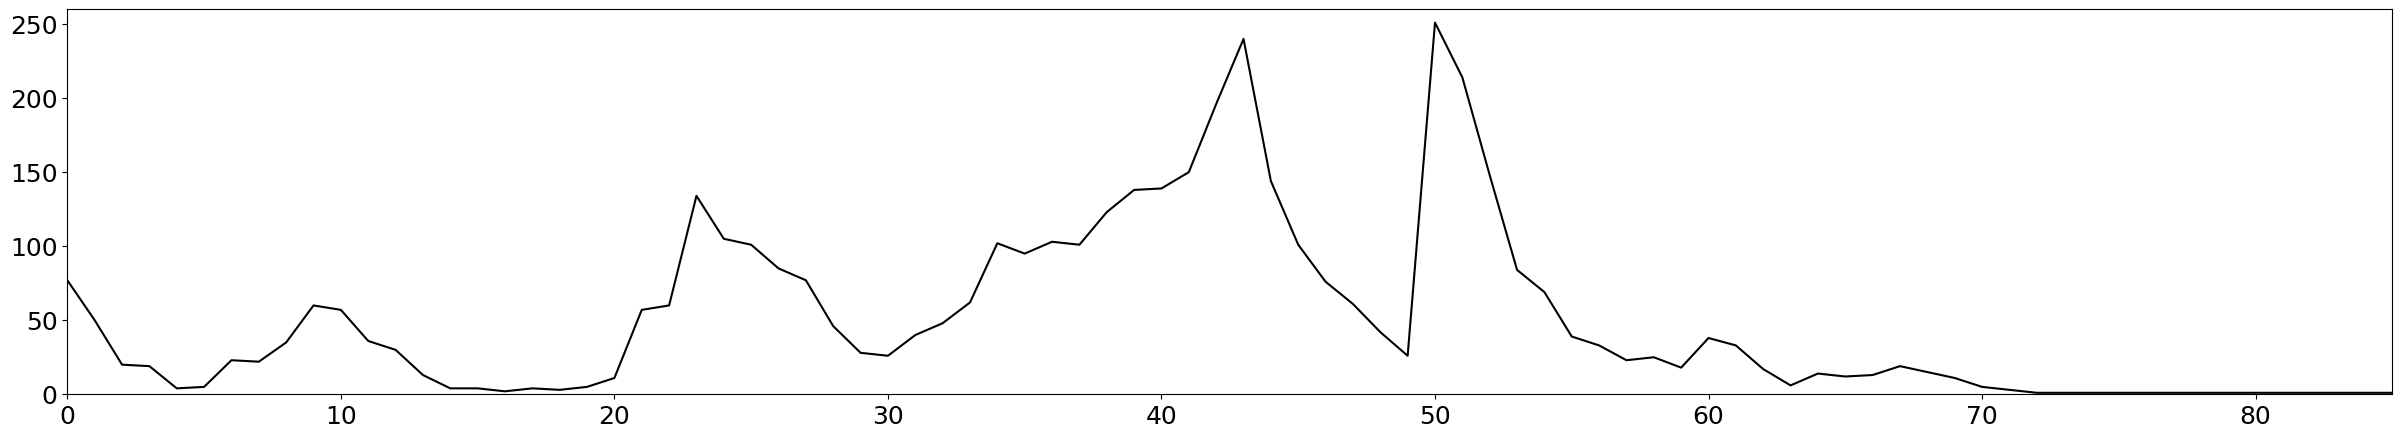

In [8]:
vanilla_iter2cpds = {}
for c, i in fm.scope.cpd_iteration_dict.items():
    if i not in vanilla_iter2cpds.keys():
        vanilla_iter2cpds[i] = [c]
    else:
        vanilla_iter2cpds[i].append(c)
        
vanilla_iter2cpdsNum = {}
for i in vanilla_iter2cpds.keys():
    vanilla_iter2cpdsNum[i] = len(vanilla_iter2cpds[i])
    
plt.figure(figsize=(30, 5))
plt.plot(vanilla_iter2cpdsNum.values(), color='k')
plt.xlim([0, 85])
plt.ylim([0, 260])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
# plt.savefig('vanilla_iter_vs_cpds_10AA.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# annotate cpds

cpd2iter = {}
for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for i, cs in vanilla_iter2cpds.items():
        for c in cs:
            if c == cpd:
                cpd2iter[c] = i

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(vanilla_iter2cpdsNum.values(), color='k')

# annotate cpds

for c in cpd2iter:
    y = random.randint(0, 250)
    plt.text(cpd2iter[c], y, cpd2name[c], ha='center', va='bottom', color='red')
    plt.scatter(cpd2iter[c], y-5, color='red')

# plt.savefig('3B_cpds_vanilla.svg', dpi=300, bbox_inches='tight')
plt.show()

# fold-gated

In [ ]:
result = pd.read_pickle('../runs/2024-04-25_11-00-45_no_look_ahead_rules_ignore_versions_3141_cumiter_fix.pkl.gz')

In [ ]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

plt.xlim([0, 360])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# from pre-expansion
cpds = ['Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']
# from vanilla (+ FMN, AcetylCoA, isopentenyl diphosphate, oxygen)
cpds = ['C00007','C00024','C00061','C00129','Z00014', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

dict1 = result.cpds_folditer
dict2 = fm.scope.cpd_iteration_dict

# if you don't care about zorder of red vs. blue
# valid_keys, data1, data2 = todata(dict1, dict2)
# colors = ['red' if c in cpds else 'blue' for c in valid_keys]
# plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.5, label='Data Points', zorder=2)

# if you red in front of blue
booleans = [c in cpds for c in valid_keys]
data1_bool = [value for value, flag in zip(data1, booleans) if flag]
data2_bool = [value for value, flag in zip(data2, booleans) if flag]
plt.scatter(data1, data2, marker='o', color='blue', alpha = 0.1, label='Data Points', zorder=2)
plt.scatter(data1_bool, data2_bool, marker='o', color='red', alpha = 0.5, label='Data Points', zorder=3)

# annotate cpds
for c in cpds:
    plt.text(dict1[c], dict2[c], cpd2name[c], ha='center', va='bottom', color='red')

plt.ylabel('vanilla')
plt.xlabel('fold_gated')
# plt.savefig('scatter_vanilla_vs_fold_gated_key_cpds.svg')
plt.show()

In [ ]:
# bokeh

output_file("vanilla_vs_fold_gated_order.html")
p = figure(plot_width=800, plot_height=800, title="vanilla_vs_fold_gated_order")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
dict1 = {key:value for key, value in result.cpds_folditer.items() if key not in cpds}
dict2 = {key:value for key, value in fm.scope.cpd_iteration_dict.items() if key not in cpds}
valid_keys, data1, data2 = todata(dict1, dict2)

dict1_red = {key:value for key, value in result.cpds_folditer.items() if key in cpds}
dict2_red = {key:value for key, value in fm.scope.cpd_iteration_dict.items() if key in cpds}
valid_keys_red, data1_red, data2_red = todata(dict1_red, dict2_red)

source = {'x': data1, 'y': data2, 'label': [cpd2name.get(key, 'no name') for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.3)

source = {'x': data1_red, 'y': data2_red, 'label': [cpd2name.get(key, 'no name') for key in valid_keys_red]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.3)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fold_gated'
p.yaxis.axis_label = 'vanilla'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

# carbon fixation pathways: validating result from vanilla

In [29]:
cm = ['M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377']

In [36]:
cm2rn = {}

for m in cm:
    print(m, module2name[m])
    print(module2rns[m])
    cm2rn[m] = set(module2rns[m])
    
    # check if any module is satisfied in vanilla
    print(all(item in [item[:6] for item in fm.scope.rns] for item in module2rns[m]))
    
    print('')

M00165 Reductive pentose phosphate cycle (Calvin cycle)
['R01523', 'R00024', 'R01512', 'R01061', 'R01063', 'R01015', 'R01068', 'R00762', 'R01067', 'R01829', 'R01845', 'R01641', 'R01056', 'R01529']
True

M00173 Reductive citrate cycle (Arnon-Buchanan cycle)
['R01196', 'R10866', 'R00199', 'R00206', 'R00345', 'R00344', 'R00342', 'R01082', 'R02164', 'R00402', 'R00405', 'R01197', 'R00267', 'R01900', 'R01325', 'R00352', 'R01322', 'R00354']
True

M00374 Dicarboxylate-hydroxybutyrate cycle
['R01196', 'R00199', 'R00345', 'R00342', 'R01082', 'R02164', 'R00405', 'R09280', 'R09281', 'R09279', 'R10782', 'R03026', 'R01975', 'R00238']
True

M00375 Hydroxypropionate-hydroxybutylate cycle
['R00742', 'R00740', 'R09289', 'R09286', 'R03045', 'R00919', 'R01859', 'R02765', 'R00833', 'R09280', 'R09281', 'R09279', 'R10782', 'R03026', 'R01975', 'R00238']
True

M00376 3-Hydroxypropionate bi-cycle
['R00742', 'R00740', 'R09289', 'R09286', 'R03045', 'R00919', 'R01859', 'R02765', 'R00833', 'R00406', 'R02164', 'R010

In [43]:
iter2rn = {}

for rn, i in fm.scope.rn_iteration_dict.items():
    if i not in iter2rn.keys():
        iter2rn[i] = [rn]
    else:
        iter2rn[i].append(rn)
        

cm = ['M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377']
rn_list = []

for i, rns in iter2rn.items():
    # keep updating rn_list
    rn_list.extend(rns)
    
    # for each cm module, check if all rns in module are in rn_list
    for m in cm:
        if all(item in [item[:6] for item in rn_list] for item in module2rns[m]):
            print(f'{m}: {module2name[m]} is feasible at {i}')
            cm.remove(m)

M00165: Reductive pentose phosphate cycle (Calvin cycle) is feasible at 37
M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) is feasible at 59
M00173: Reductive citrate cycle (Arnon-Buchanan cycle) is feasible at 67
M00374: Dicarboxylate-hydroxybutyrate cycle is feasible at 68
M00375: Hydroxypropionate-hydroxybutylate cycle is feasible at 71
M00376: 3-Hydroxypropionate bi-cycle is feasible at 72


# checking cofactor dependence: two directions

In [ ]:
cpd2name['C00003'], cpd2name['C01352']

In [ ]:
# FAD+/FADH2

for rn, cpds in rn2cpds_SI.items():
    if 'C00016' in cpds:
        if 'C01352' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))
print('-----')
for rn, cpds in rn2cpds_SI.items():
    if 'C01352' in cpds:
        if 'C00016' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))

In [ ]:
# NAD+/NADH

for rn, cpds in rn2cpds_SI.items():
    if 'C00003' in cpds:
        if 'C00004' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))
print('-----')
for rn, cpds in rn2cpds_SI.items():
    if 'C00004' in cpds:
        if 'C00003' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))

In [ ]:
# NADP+/NADPH

for rn, cpds in rn2cpds_SI.items():
    if 'C00005' in cpds:
        if 'C00006' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))
print('-----')
for rn, cpds in rn2cpds_SI.items():
    if 'C00006' in cpds:
        if 'C00005' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))

In [ ]:
# ATP/ADP

for rn, cpds in rn2cpds_SI.items():
    if 'C00002' in cpds:
        if 'C00008' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))
print('-----')
for rn, cpds in rn2cpds_SI.items():
    if 'C00008' in cpds:
        if 'C00002' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))

In [ ]:
# SAM/SAH

for rn, cpds in rn2cpds_SI.items():
    if 'C00019' in cpds:
        if 'C00021' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))
print('-----')
for rn, cpds in rn2cpds_SI.items():
    if 'C00021' in cpds:
        if 'C00019' not in cpds:
            print(rn, cpds, rn2def_SI.get(rn[:6], 0))

# ~50% of seed reactions are never reached!

In [ ]:
len(fm.seed.cpds)

In [ ]:
len(fm.seed.rns - fm.scope.rns)  # number of rns in seed that the algo never reaches

In [ ]:
len(fm.seed.rns), len(fm.scope.rns), len(fm.seed.rns & fm.scope.rns)

# get seed sets for pre-expansion

In [2]:
preexp_cpds = ['Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

cpd2seeds = {}
cpd2seeds['NONE'] = fm.seed.cpds

for cpd in preexp_cpds:
    seeds = []
    cpditer = fm.scope.cpd_iteration_dict[cpd]
    for c, i in fm.scope.cpd_iteration_dict.items():
        if i <= cpditer:
            seeds.append(c)
    cpd2seeds[cpd] = seeds

cpd2seeds['ALL'] = fm.scope.cpds

In [3]:
for c, seeds in cpd2seeds.items():
    print(c, len(seeds))

NONE 80
Z00035 255
C00002 484
C00004 601
C00019 1203
C00010 1291
C00016 1353
Z00047 1550
Z00009 3995
ALL 4294


In [6]:
# for cpd, seeds in cpd2seeds.items():
#     with open(f'../data/pre-expansion_seed_cpds/pre-expansion_seed_cpds_{cpd}.pkl', 'wb') as file:
#         pickle.dump(seeds, file)

### TableS1

In [15]:
for c in fm.scope.cpds:
    if cpd2name.get(c, 'NONE') == 'NONE':
        print(c)

C20797
C15778
MeCobamineCofactor
C20798


In [28]:
cpd2name = csv2dict('../data/assets/cpd2name.csv')
pre2label = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}

df = pd.DataFrame(columns=['Pre-expansion', 'ID', 'Description'])
seen = set()

data = []
for pre in cpd2seeds.keys():
    l = len(cpd2seeds[pre])
    for c in sorted(cpd2seeds[pre]):
        if c not in seen:
            data.append({
                'Pre-expansion': f'{pre2label[pre]} ({l})',
                'ID': c,
                'Description': cpd2name.get(c, c)
            })
        seen.add(c)

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Pre-expansion,ID,Description
0,NONE (80),C00001,H2O; Water
1,NONE (80),C00009,Orthophosphate; Phosphate; Phosphoric acid; Or...
2,NONE (80),C00011,CO2; Carbon dioxide
3,NONE (80),C00012,Peptide
4,NONE (80),C00014,Ammonia; NH3


In [30]:
# df.to_csv('TableS1.csv', index=False)

# investigating photosyn_R09503_vX

In [ ]:
rn2eqn_SI['R09503_vX']

In [ ]:
rn2eqn_SI['R09503_v1']

In [ ]:
# according to Liam: new reactions were added to account for the possibility that ancient reactions 
# could be catalyzed with prebiotic, geochemical context; so these reactions are NOT meant to be the same; 
# some of them are not fold-gated

# Shuffle1

In [ ]:
# shuffle2 was done with multiprocessing using .py file

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import networkExpansionPy.folds as nf
import pandas as pd
from pathlib import PurePath
import random

def shuffle_dict_pairs(d):
    # Extract keys and values
    keys = list(d.keys())
    values = list(d.values())

    # Shuffle the keys
    random.shuffle(keys)

    # Create a new dictionary with shuffled key-value pairs
    shuffled_dict = dict(zip(keys, values))

    return shuffled_dict


if __name__ == '__main__':

    asset_path = nf.asset_path

    # for vanilla
    METABOLISM_PATH = PurePath(asset_path, "metabolic_networks",
                               "metabolism.v8.02Jun2024_peroxide_fix.pkl")  # path to metabolism object pickle
    RN2RULES_PATH = PurePath(asset_path, "rn2fold", "rn2rules.20230224.pkl")  # path to rn2rules object pickle
    SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv")  # path to seed compounds csv

    # for FOLD-GATED
    ALGORITHM = "no_look_ahead_rules"
    WRITE = True  # write result to disk
    WRITE_TMP = False  # write after each iteration
    CUSTOM_WRITE_PATH = None  # if writing result, custom path to write to
    ORDERED_OUTCOME = False  # ignore random seed and always choose folds based on sort order
    IGNORE_REACTION_VERSIONS = True  # when maximizing for reactions, don't count versioned reactions

    ## Metabolism
    metabolism = pd.read_pickle(METABOLISM_PATH)

    ## FoldRules
    rn2rules = pd.read_pickle(RN2RULES_PATH)
    RANDOMSEED = 33671
    random.seed(RANDOMSEED)
    # set file name
    STR_TO_APPEND_TO_FNAME = "shuffle1_%s" % RANDOMSEED

    # Inititalize fold metabolism with shuffling
    rn2rules_shuffle = shuffle_dict_pairs(rn2rules)  # Shuffle the dictionary pairs
    foldrules = nf.FoldRules.from_rn2rules(rn2rules_shuffle)
    fm = nf.FoldMetabolism(metabolism, foldrules, seed)

    ## Modify seeds with AA and GATP_rns
    aa_cids = set(["C00037",
                   "C00041",
                   "C00065",
                   "C00188",
                   "C00183",
                   "C00407",
                   "C00123",
                   "C00148",
                   "C00049",
                   "C00025"])

    GATP_rns = {'R00200_gATP_v1',
                'R00200_gATP_v2',
                'R00430_gGTP_v1',
                'R00430_gGTP_v2',
                'R01523_gATP_v1',
                'R04144_gATP_v1',
                'R04208_gATP',
                'R04463_gATP',
                'R04591_gATP_v1',
                'R06836_gATP',
                'R06974_gATP',
                'R06975_gATP_v1'}

    
    # Seed with pre-expansion
    preATP = pd.read_pickle('../data/pre-expansion_seed_cpds/pre-expansion_seed_cpds_C00002.pkl')
    seed = nf.Params(
        rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = set(preATP) | aa_cids,
        folds = set(['spontaneous'])
    )

    ## Seed (no pre-expansion)
    # seed = nf.Params(
    #     rns=set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions
    #     cpds=set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
    #     folds=set(['spontaneous'])
    # )

## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)

# run FOLD-GATED expansion
result = fm.rule_order(algorithm=ALGORITHM, write=WRITE, write_tmp=WRITE_TMP, path=CUSTOM_WRITE_PATH, str_to_append_to_fname=STR_TO_APPEND_TO_FNAME, ordered_outcome=ORDERED_OUTCOME, ignore_reaction_versions=IGNORE_REACTION_VERSIONS)

# Leave One Out (LOO)

## fold ablation

In [ ]:
all_xgroups = ['fold_independent', 'spontaneous', '2002', '1', '2487', '2006', '2003', '7518', '4126', '7542', '246', '218', '2007', '7525', '304', '12', '11', '109', '10', '210', '7515', '279', '7577', '3016', '281', '7528', '331', '301', '7572', '2011', '206', '325', '282', '7527', '805', '180', '7512', '7560', '7529', '3691', '7579', '62', '315', '7554', '70', '4002', '2485', '2004', '297', '205', '7580', '286', '208', '247', '7567', '7510', '3156', '2', '307', '212', '387', '7561', '5104', '7571', '5', '7516', '7517', '7574', '911', '611', '132', '283', '3651', '2005', '2498', '4081', '7573', '632', '103', '328', '64', '708', '302', '2484', '7520', '185', '221', '2492', '7543', '211', '810', '285', '2493', '7523', '4021', '298', '7541', '7552', '164', '3847', '149', '4020', '4045', '355', '4178', '108', '4018', '7587', '7546', '7507', '812', '101', '4019', '223', '3339', '702', '7601', '7602', '144', '3374', '278', '604', '7588', '602', '4952', '4953', '7524', '236', '131', '129', '159', '7581', '2486', '7531', '222', '213', '7504', '6094', '3692', '4004', '220', '330', '7558', '230', '314', '207', '65', '376', '276', '503', '7501', '244', '7522', '323', '7514', '107', '3294', '217', '187', '219', '239', '243', '3883', '7564', '266', '147', '321', '312', '296', '3687', '150', '3699', '5084', '868', '1001', '327', '3688', '375', '4995', '7589', '73', '133', '3371', '7568', '7509', '300', '277', '141', '7534', '3754', '2500', '1074', '102', '136', '316', '209', '139', '601', '4093', '177', '371', '873', '4279', '5038', '813', '5069', '7500', '3257', '172', '629', '232', '3052', '275', '6075', '7553', '3264', '231', '179', '189', '7539', '830', '377', '270', '313', '6051', '106', '3654', '7586', '258', '6058', '3117', '3292', '4114', '3086', '1077', '3599', '6113', '7550', '1137', '4262', '3005', '69', '7536', '7549', '214', '4', '3686', '148', '3896', '3076', '633', '4033', '4052', '3794', '2008', '1119', '4161', '319', '268', '5067', '9', '3447', '4029', '4049', '7584', '4011', '4237', '4111', '608', '7604', '7551', '525', '875', '880', '3858', '582', '4194', '374', '7513', '3740', '1143', '1055', '1114', '7595', '7562', '814', '197', '842', '650', '869', '5039', '7521', '623', '1144', '6096', '4022', '4044', '237', '5100', '4295', '7540', '309', '253', '303', '199', '3001', '4335', '3685', '324', '3009', '528', '4076', '876', '4017', '2496', '3697', '3892', '3997', '146', '262', '867', '914', '2012', '7', '3249', '158', '557', '66', '4294', '6166', '257', '3978', '620', '6174', '6', '4159', '4110', '235', '7556', '581', '3960', '154', '640', '5103', '3752', '3777', '3115', '4160', '196', '305', '3207', '881', '241', '284', '3321', '3323', '3322', '920', '378', '7544', '184', '4983', '4229', '4971', '4223', '590', '2010', '169', '806', '228', '192', '603', '306', '75', '3018', '865', '872', '3269', '7563', '3623', '4048', '4028', '7578', '3993', '3994', '3500', '3304', '4025', '4024', '4046', '4272', '3281', '3843', '3456', '3579', '4035', '4054', '4036']
len(all_xgroups)

import networkExpansionPy.folds as nf
import pandas as pd
from collections import Counter
from pathlib import PurePath, Path

for x in all_xgroups:
    xgroups = copy.copy(all_xgroups)
    xgroups.remove(x)

    start_time = time.time()

    # seed = sys.argv[1]
    # random.seed(seed)
    asset_path = nf.asset_path

    # for vanilla
    METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
    RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
    SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

    # for FOLD-GATED
    ALGORITHM = "no_look_ahead_rules"
    WRITE = True # write result to disk
    WRITE_TMP = False # write after each iteration
    CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
    STR_TO_APPEND_TO_FNAME = f'{x}' # if writing result, str to append to filename
    ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
    IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

    ## Metabolism
    metabolism = pd.read_pickle(METABOLISM_PATH)
    # remove reactions that produce H2O2 before O2
    H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
    condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
    metabolism.network = metabolism.network[~condition]
    assert 'R00017_v1' not in list(metabolism.network['rn'])


    ## FoldRules
    rn2rules = pd.read_pickle(RN2RULES_PATH)
    foldrules = nf.FoldRules.from_rn2rules(rn2rules)

    ## Modify seeds with AA and GATP_rns
    aa_cids = set(["C00037",
        "C00041",
        "C00065",
        "C00188",
        "C00183",
        "C00407",
        "C00123",
        "C00148",
        "C00049",
        "C00025"]) 

    GATP_rns = {'R00200_gATP_v1',
        'R00200_gATP_v2',
        'R00430_gGTP_v1',
        'R00430_gGTP_v2',
        'R01523_gATP_v1',
        'R04144_gATP_v1',
        'R04208_gATP',
        'R04463_gATP',
        'R04591_gATP_v1',
        'R06836_gATP',
        'R06974_gATP',
        'R06975_gATP_v1'}

    ## Seed
    seed = nf.Params(
        rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions
        cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
        folds = set(xgroups)
    )

    ## Inititalize fold metabolism
    fm = nf.FoldMetabolism(metabolism, foldrules, seed)

    # run FOLD-GATED expansion
    result = fm.rule_order(algorithm=ALGORITHM, write=WRITE, write_tmp=WRITE_TMP, path=CUSTOM_WRITE_PATH, str_to_append_to_fname=STR_TO_APPEND_TO_FNAME, ordered_outcome=ORDERED_OUTCOME, ignore_reaction_versions=IGNORE_REACTION_VERSIONS)

    print("--- %s seconds ---" % (time.time() - start_time))

## reaction ablation

In [19]:
comp2essential_rns = csv2dict('/Users/longolab/Downloads/comp2essential_rns_rest.csv')
len(comp2essential_rns)

240

In [ ]:
for comp, e_rns in comp2essential_rns.items():

    # skip if no essential reactions
    if len(e_rns) == 0:
        continue
    
    xgroups = copy.copy(all_xgroups)

    start_time = time.time()

    # seed = sys.argv[1]
    # random.seed(seed)
    asset_path = nf.asset_path

    # for vanilla
    METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
    RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
    SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

    # for FOLD-GATED
    ALGORITHM = "no_look_ahead_rules"
    WRITE = True # write result to disk
    WRITE_TMP = False # write after each iteration
    CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
    STR_TO_APPEND_TO_FNAME = f'{comp}' # if writing result, str to append to filename
    ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
    IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

    ## Metabolism
    metabolism = pd.read_pickle(METABOLISM_PATH)
    # remove reactions that produce H2O2 before O2
    H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
    condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
    metabolism.network = metabolism.network[~condition]
    assert 'R00017_v1' not in list(metabolism.network['rn'])

    # ablate reactions
    condition2 = metabolism.network['rn'].isin(set(e_rns))
    metabolism.network = metabolism.network[~condition2]

    ## FoldRules
    rn2rules = pd.read_pickle(RN2RULES_PATH)
    foldrules = nf.FoldRules.from_rn2rules(rn2rules)

    ## Modify seeds with AA and GATP_rns
    aa_cids = set(["C00037",
        "C00041",
        "C00065",
        "C00188",
        "C00183",
        "C00407",
        "C00123",
        "C00148",
        "C00049",
        "C00025"]) 

    GATP_rns = {'R00200_gATP_v1',
        'R00200_gATP_v2',
        'R00430_gGTP_v1',
        'R00430_gGTP_v2',
        'R01523_gATP_v1',
        'R04144_gATP_v1',
        'R04208_gATP',
        'R04463_gATP',
        'R04591_gATP_v1',
        'R06836_gATP',
        'R06974_gATP',
        'R06975_gATP_v1'}

    ## Seed
    seed = nf.Params(
        rns = (set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns) - set(e_rns),  # start with non-fold-gated reactions
        cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
        folds = set(xgroups)
    )

    ## Inititalize fold metabolism
    fm = nf.FoldMetabolism(metabolism, foldrules, seed)

    # run FOLD-GATED expansion
    result = fm.rule_order(algorithm=ALGORITHM, write=WRITE, write_tmp=WRITE_TMP, path=CUSTOM_WRITE_PATH, str_to_append_to_fname=STR_TO_APPEND_TO_FNAME, ordered_outcome=ORDERED_OUTCOME, ignore_reaction_versions=IGNORE_REACTION_VERSIONS)

    print("--- %s seconds ---" % (time.time() - start_time))

calculating scope...


/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:535: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
Modified reaction iteration dict


/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:535: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)
/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:537: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  x,y = netExp_step(R,P,x0,b)


No foldsets remaining.
rule iter: 2 (6.7 sec) frozenset()
Final results written to:
/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/fold_results/2025-03-18_12-31-40_frozenset({'6', '10', '11', '5'}).pkl.gz
--- 12.009253978729248 seconds ---
calculating scope...


...

No foldsets remaining.
rule iter: 2 (6.9 sec) frozenset()
Final results written to:
/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/fold_results/2025-03-18_12-57-35_frozenset({'101', '244', '1', '375', '304'}).pkl.gz
--- 11.333936214447021 seconds ---
calculating scope...


/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:535: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
Modified reaction iteration dict


/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:535: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)
/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:537: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  x,y = netExp_step(R,P,x0,b)


No foldsets remaining.
rule iter: 2 (6.8 sec) frozenset()
Final results written to:
/Users/longolab/Desktop/LongoLab/Fold_Gated/networkExpansion/fold_results/2025-03-18_12-57-46_frozenset({'231', '179', '325', '217'}).pkl.gz
--- 11.273229837417603 seconds ---
calculating scope...
